# E — Segmentation (clustering) — EventZilla

**Objectif** : comparer **≥ 2 modèles** (K-Means vs agglomératif Ward) sur données **standardisées** ; métriques **silhouette**, **Davies-Bouldin**, **coude** ; viz **PCA 2D**, **heatmap des centres**.

Ici on ne prédit pas une étiquette « vraie » : on cherche des **groupes homogènes** pour alimenter la stratégie commerciale ou opérationnelle (ciblage, messages, priorisation). Les scores (silhouette, DB) répondent à la question « les clusters sont-ils **serrés** et **bien séparés** ? », pas à « accuracy ».

**Données** :
- **Notebook (sections 2–4)** : vue large `SQL_ML_PERFORMANCE_WIDE` (une ligne de fait) — pédagogie critère **E**.
- **Déploiement fidélité** : agrégats RFM par bénéficiaire / prestataire → `python ML/scripts/run_01_clustering.py` + `metrics_clustering.json` (`modes`).

**Grille E** : ≥2 algorithmes, évaluation silhouette / DB / coude, profilage segments (heatmap, PCA).

**Modèles** : K-Means (partitions, centres) vs hiérarchique Ward (structure sans sphéricité). Pour le détail **critère B** (intuition, hypothèses, limites), voir **`06_B_comprehension_modeles.ipynb`**.

Références : dashboards PDF / doc KPI EventZilla.


## Contexte — clustering non supervisé

| | |
|--|--|
| **Entrées** | Wide performance **ou** agrégats fidélité (`*_loyalty`) |
| **Sortie** | Étiquette cluster 0…k−1 (proximité en espace **standardisé**) |
| **Usage BI** | Typologie **complémentaire** aux KPI DAX ; nommer les segments via **heatmap** |

Sans standardisation, une variable à grande variance (ex. montant) **écrase** les autres dans la distance euclidienne : les segments refléteraient surtout l’échelle, pas le profil métier. D’où l’usage systématique de données **mises à l’échelle** comme en **00_A**.

**Attention** : les libellés métier (VIP, fidèle…) viennent de l’**analyse des centres**, pas du modèle seul.


## Notebook « wide » vs pipeline fidélité

| Voie | Rôle |
|------|------|
| **Sections 2–4** | Critère **E** sur `SQL_ML_PERFORMANCE_WIDE` : coude, silhouette, 2 modèles, PCA, heatmap |
| **`run_01_clustering.py`** | Artefacts Streamlit : `kmeans_loyalty_*.joblib`, JSON segments fidélité |

Ne pas confondre les **profils ligne de fait** (wide) avec les **profils agrégés** (RFM).

En rédaction de rapport, précisez toujours **quelle voie** vous commentez : un cluster « riche » sur la wide peut signifier une **ligne de réservation** atypique, alors que sur la fidélité il désigne plutôt un **comportement agrégé** (fréquence, montant cumulé). Les deux sont valides, mais les **storytelling** diffèrent.


## Référence critère E

| Exigence | Ici |
|----------|-----|
| ≥ 2 modèles | K-Means, Agglomératif (Ward) |
| Évaluation | Silhouette ↑, Davies-Bouldin (bas = mieux), coude |
| Viz | PCA 2D, heatmap centres |

**B** : K-Means suppose des groupes compacts ; Ward hiérarchique sans fixer la forme des clusters.

**Lecture rapide des métriques** : silhouette **élevée** → points en moyenne **plus proches** de leur cluster que des autres ; **Davies-Bouldin** **bas** → clusters **compacts** et **éloignés** les uns des autres. Le **coude** sur l’inertie (WCSS) aide à choisir un **k** raisonnable sans sur-segmenter le bruit.


## 1. Connexion DW

Même serveur / base que SSMS. Exécuter en premier : test `DB_NAME()` / ODBC.

Si la connexion échoue, tout le reste du notebook (requêtes wide, chargement des features) sera incohérent ou vide : corrigez **d’abord** le moteur SQL, le driver ODBC et les variables d’environnement décrites dans **00_A**, puis relancez cette cellule avant les extractions.


In [1]:
from pathlib import Path
import sys
REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT != REPO_ROOT.parent:
    if (REPO_ROOT / "ML" / "ml_paths.py").is_file():
        break
    REPO_ROOT = REPO_ROOT.parent
if not (REPO_ROOT / "ML" / "ml_paths.py").is_file():
    raise FileNotFoundError("Ouvrez Jupyter depuis la racine du dépôt (dossier contenant ML/)")
sys.path.insert(0, str(REPO_ROOT))

# Connexion DW — diagnostic (même serveur / base que SSMS)
from ML.ml_paths import (
    DATABASE_DW,
    SQL_SERVER,
    SQL_DRIVER,
    SQL_PORT,
    build_windows_auth_uri,
    get_sql_engine,
    ml_sql_only,
    read_dw_sql,
    sql_engine_init_error,
)

print("=" * 62)
print(" EVENTZILLA — Connexion DW (équivalent accès SSMS)")
print("=" * 62)
print("  Serveur SQL      :", SQL_SERVER + (":" + str(SQL_PORT) if SQL_PORT else ""))
print("  Base DW cible    :", DATABASE_DW)
print("  Driver ODBC      :", SQL_DRIVER)
print("  Mode DW seul     :", ml_sql_only(), "(EVENTZILLA_ML_SQL_ONLY=1 → pas de Excel/CSV)")
try:
    _uri = build_windows_auth_uri()
    print("  Chaîne (extrait) :", (_uri[:88] + "…") if len(_uri) > 88 else _uri)
except Exception as _uerr:
    print("  Chaîne URI       : erreur", _uerr)
_eng = get_sql_engine()
if _eng is not None:
    try:
        _chk = read_dw_sql(
            "SELECT DB_NAME() AS base_active, CAST(SERVERPROPERTY('ServerName') AS NVARCHAR(128)) AS serveur",
            _eng,
        )
        print("  Test SQL         : OK — même base que sous SSMS si base_active =", DATABASE_DW)
        print(_chk.to_string(index=False))
    except Exception as _qerr:
        print("  Test SQL         : ÉCHEC —", _qerr)
else:
    print("  Engine           : ABSENT —", sql_engine_init_error() or "voir pip sqlalchemy pyodbc")
print("=" * 62)


 EVENTZILLA — Connexion DW (équivalent accès SSMS)
  Serveur SQL      : ASUSRANIM
  Base DW cible    : DW_eventzella
  Driver ODBC      : ODBC Driver 17 for SQL Server
  Mode DW seul     : True (EVENTZILLA_ML_SQL_ONLY=1 → pas de Excel/CSV)
  Chaîne (extrait) : mssql+pyodbc://@ASUSRANIM/DW_eventzella?driver=ODBC+Driver+17+for+SQL+Server&trusted_con…
  Test SQL         : OK — même base que sous SSMS si base_active = DW_eventzella
  base_active   serveur
DW_eventzella AsusRanim


### Après connexion

`Test SQL : OK` + base = **DW** attendue. Sinon : pyodbc / SQLAlchemy (`ml_paths.py`).


## Figures Matplotlib

Rendu **inline** sous la cellule avec `plt.show()`. Si vide : exécuter les cellules **dans l’ordre** ; `%matplotlib inline` en tête si besoin.

## 2. Imports & données

Attendu : message prêt clustering + `ML_SQL_ONLY` affiché.


In [2]:
from pathlib import Path
import sys
REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT != REPO_ROOT.parent:
    if (REPO_ROOT / "ML" / "ml_paths.py").is_file():
        break
    REPO_ROOT = REPO_ROOT.parent
if not (REPO_ROOT / "ML" / "ml_paths.py").is_file():
    raise FileNotFoundError("Ouvrez Jupyter depuis la racine du dépôt (dossier contenant ML/)")
sys.path.insert(0, str(REPO_ROOT))

%matplotlib inline
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import davies_bouldin_score, silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from ML.ml_paths import ML_PROCESSED, ML_MODELS, ensure_processed_dirs, get_sql_engine, ml_sql_only, read_dw_sql
from ML.schema_eventzilla import (
    CLUSTERING_NUMERIC_DROP,
    SQL_ML_CLUSTERING_LOYALTY_BENEFICIARY,
    SQL_ML_CLUSTERING_LOYALTY_PROVIDER,
    SQL_ML_PERFORMANCE_WIDE,
)
from ML.cluster_labels import cluster_labels_from_centers

sns.set_theme(style="whitegrid")
ensure_processed_dirs()
ML_MODELS.mkdir(parents=True, exist_ok=True)
feat_names: list[str] = []
print("[1] ✅ Prêt pour le clustering (critère E : K-Means vs Agglomératif). ML_SQL_ONLY:", ml_sql_only())


[1] ✅ Prêt pour le clustering (critère E : K-Means vs Agglomératif). ML_SQL_ONLY: True


### Après imports

Libs OK ; `ML_SQL_ONLY=True` impose le DW pour la suite.


### Jeu « wide » (exploration E)

Chargement `SQL_ML_PERFORMANCE_WIDE` → imputation médiane → **StandardScaler** → sous-échantillon `X_work` (plafond lignes).

**Lecture** : dimensions (n, p) ; standardisation **obligatoire** avant distances.


In [3]:
X_for_cluster = None
engine = get_sql_engine()
if engine is not None:
    try:
        df = read_dw_sql(SQL_ML_PERFORMANCE_WIDE, engine)
        if len(df) == 0:
            raise ValueError("0 ligne (performance DW)")
        drop_cols = [c for c in CLUSTERING_NUMERIC_DROP if c in df.columns]
        num = df.select_dtypes(include=[np.number]).columns.drop(labels=drop_cols, errors="ignore")
        if len(num) == 0:
            raise ValueError("0 colonne numérique utilisable (performance DW)")
        feat_names = [str(c) for c in num]
        X_raw_mat = df[num].replace([np.inf, -np.inf], np.nan).values
        imp = SimpleImputer(strategy="median")
        scaler = StandardScaler()
        X_for_cluster = scaler.fit_transform(imp.fit_transform(X_raw_mat))
        print("[2] Source DW — forme :", X_for_cluster.shape)
    except Exception as e:
        print("[2] DW indisponible :", e)

if X_for_cluster is None:
    if ml_sql_only():
        raise RuntimeError(
            "[2] SQL DW obligatoire (EVENTZILLA_ML_SQL_ONLY=1) ou ML_SQL_ONLY=0 + 00."
        )
    raw_fp = ML_PROCESSED / "X_raw_numeric.npy"
    if not raw_fp.is_file():
        raise FileNotFoundError("[2] Exécuter d'abord le critère A (`00_A_preparation_donnees_feature_engineering.ipynb`) — X_raw_numeric.npy manquant.")
    X_raw_mat = np.load(raw_fp)
    feat_names = [f"dim_{i}" for i in range(X_raw_mat.shape[1])]
    imp = SimpleImputer(strategy="median")
    scaler = StandardScaler()
    X_for_cluster = scaler.fit_transform(imp.fit_transform(X_raw_mat))
    print("[2] Source 00 — forme :", X_for_cluster.shape)

N_CAP = min(8000, len(X_for_cluster))
X_work = X_for_cluster[:N_CAP]
print("[2] Sous-échantillon X_work :", X_work.shape)


[2] Source DW — forme : (3382, 12)
[2] Sous-échantillon X_work : (3382, 12)


### Aperçu fidélité (optionnel)

Requêtes `SQL_ML_CLUSTERING_LOYALTY_*` : une ligne par **bénéficiaire** ou **prestataire**. Entraînement complet : `run_01_clustering.py`.


In [4]:
engine_rf = get_sql_engine()
if engine_rf is not None:
    for _label, _sql in (
        ("Bénéficiaires (RFM)", SQL_ML_CLUSTERING_LOYALTY_BENEFICIARY),
        ("Prestataires (RFM)", SQL_ML_CLUSTERING_LOYALTY_PROVIDER),
    ):
        try:
            _df = read_dw_sql(_sql, engine_rf)
            print(f"[2b] {_label} — forme {_df.shape} (aperçu 3 lignes)")
            print(_df.head(3).to_string())
        except Exception as _e:
            print(f"[2b] {_label} — impossible : {_e}")
else:
    print("[2b] Engine SQL absent — sautez l'aperçu fidélité.")


[2b] Bénéficiaires (RFM) — forme (2230, 7) (aperçu 3 lignes)
   id_beneficiary  nb_reservations_loyalty  ca_total_loyalty  panier_moyen_loyalty  recency_days_loyalty  avg_nb_visitors_loyalty  volume_reservations_site_loyalty
0           19912                      2.0           13855.0                6927.5                1363.0                   3343.5                             276.0
1           19914                      2.0           14203.0                7101.5                1371.0                    725.5                             181.0
2           19919                      2.0           14543.0                7271.5                1530.0                   1688.0                             258.0
[2b] Prestataires (RFM) — forme (714, 7) (aperçu 3 lignes)
   id_provider  nb_reservations_loyalty  ca_total_loyalty  panier_moyen_loyalty  recency_days_loyalty  avg_nb_visitors_loyalty  volume_reservations_site_loyalty
0         3722                      5.0           54636.0      

### Après chargement wide

**X_work** : sous-échantillon pour temps de calcul. **StandardScaler** : évite qu’une variable à forte variance domine K-Means / Ward.


## 3. Choix de k & comparaison des modèles

**Holdout** (indices) : stabilité silhouette K-Means train vs test sur la grille de k.

**Ensuite** : même **k** pour K-Means et agglomératif → comparer **silhouette** et **Davies-Bouldin**.


### Graphiques : coude & silhouette

- **Coude (inertie)** : au-delà du coude, ajouter des clusters **réduit peu** l’inertie.
- **Silhouette vs k** : k élevé localement = meilleure séparation **sur cette grille** (à croiser avec le coude).



### Grille k — parcours des k : inertie (WCSS), silhouette ; choix `k_best` (ex. max silhouette sur plage).

**Après exécution** : vérifier cohérence **visuelle** coude + silhouette (éviter k trop grand si gain marginal).


[3] k retenu (max silhouette sur plage) : 3 | plage : [2, 3, 4, 5, 6, 7, 8, 9, 10]

--- Lecture coude / silhouette ---
Coude (graphique gauche) : repérez le pli de la courbe inertie vs k ; au-delà, le gain marginal faiblit.
Gains marginaux WCSS : 2->3: 2707 | 3->4: 1730 | 4->5: 2306 | 5->6: 2756 | 6->7: 864 | 7->8: 2471 | 8->9: 764 | 9->10: 798
Silhouette (graphique droit) : k_best = 3 maximise la silhouette sur la grille — croiser avec le coude pour éviter un k trop grand.

→ Interprétation : silhouette max faible (< 0,25) — chevauchement marqué entre groupes (données continues ou bruit).
Indice coude (WCSS) : plus forte baisse entre k=5 et k=6 (gain 2756).
  Plus faible baisse entre k=8 et k=9 (gain 764) — zone où ajouter des clusters aide peu.


C:\Users\ranim\AppData\Local\Temp\ipykernel_376\1887673779.py:60: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ranim\AppData\Local\Temp\ipykernel_376\1887673779.py:60: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ranim\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ranim\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


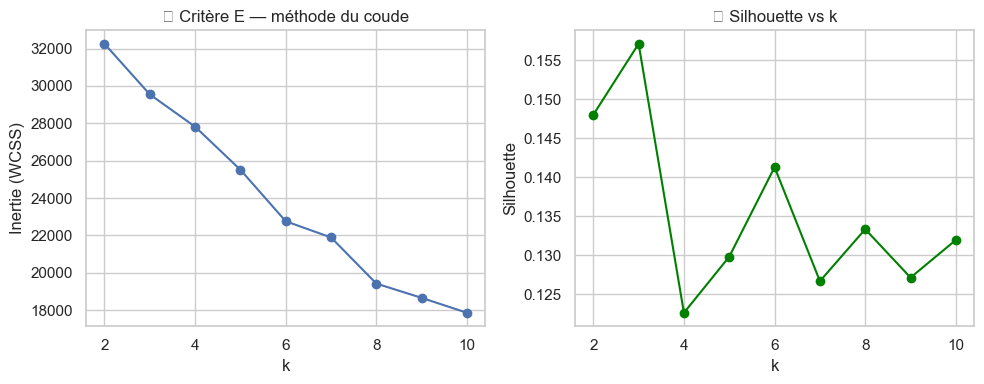

In [5]:
K_hi = min(10, max(3, len(X_work) // 200))
K_range = range(2, K_hi + 1)
inertias = []
sil_by_k = []
for k in K_range:
    km_i = KMeans(n_clusters=k, random_state=42, n_init=10)
    lab_i = km_i.fit_predict(X_work)
    inertias.append(float(km_i.inertia_))
    sil_by_k.append(float(silhouette_score(X_work, lab_i)))
k_best = int(list(K_range)[int(np.argmax(sil_by_k))])
print("[3] k retenu (max silhouette sur plage) :", k_best, "| plage :", list(K_range))

print("\n--- Lecture coude / silhouette ---")
print("Coude (graphique gauche) : repérez le pli de la courbe inertie vs k ; au-delà, le gain marginal faiblit.")
kr = list(K_range)
marg = []
if len(inertias) > 1:
    marg = [inertias[i] - inertias[i + 1] for i in range(len(inertias) - 1)]
    print(
        "Gains marginaux WCSS : "
        + " | ".join(f"{kr[i]}->{kr[i + 1]}: {m:.0f}" for i, m in enumerate(marg))
    )
print(
    "Silhouette (graphique droit) : k_best =",
    k_best,
    "maximise la silhouette sur la grille — croiser avec le coude pour éviter un k trop grand.",
)
_max_sil = float(np.max(sil_by_k))
if _max_sil < 0.25:
    print(
        "\n→ Interprétation : silhouette max faible (< 0,25) — chevauchement marqué entre groupes (données continues ou bruit)."
    )
elif _max_sil < 0.5:
    print(
        "\n→ Interprétation : silhouette modérée — structure présente mais frontières floues entre segments."
    )
else:
    print(
        "\n→ Interprétation : silhouette relativement élevée sur cette plage — séparation des clusters plus nette."
    )
if len(marg) >= 1:
    imax = int(np.argmax(marg))
    imin = int(np.argmin(marg))
    print(
        f"Indice coude (WCSS) : plus forte baisse entre k={kr[imax]} et k={kr[imax + 1]} (gain {marg[imax]:.0f})."
    )
    print(
        f"  Plus faible baisse entre k={kr[imin]} et k={kr[imin + 1]} (gain {marg[imin]:.0f}) — zone où ajouter des clusters aide peu."
    )

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(list(K_range), inertias, "o-")
ax[0].set_xlabel("k")
ax[0].set_ylabel("Inertie (WCSS)")
ax[0].set_title("📉 Critère E — méthode du coude")
ax[1].plot(list(K_range), sil_by_k, "o-", color="green")
ax[1].set_xlabel("k")
ax[1].set_ylabel("Silhouette")
ax[1].set_title("📈 Silhouette vs k")
plt.tight_layout()
plt.show()


### K-Means vs Ward (même k)

**Silhouette** plus haute → meilleure cohésion / séparation ; **Davies-Bouldin** plus bas → clusters plus compacts et séparés.

Conclure **quel algorithme** est préféré **sur ce jeu** pour le critère E.


In [6]:
km_model = KMeans(n_clusters=k_best, random_state=42, n_init=10)
labels_km = km_model.fit_predict(X_work)
agg = AgglomerativeClustering(n_clusters=k_best, linkage="ward")
labels_agg = agg.fit_predict(X_work)

sil_km = float(silhouette_score(X_work, labels_km))
sil_agg = float(silhouette_score(X_work, labels_agg))
db_km = float(davies_bouldin_score(X_work, labels_km))
db_agg = float(davies_bouldin_score(X_work, labels_agg))
print("[3] Comparaison (même k=%d) :" % k_best)
print("     Silhouette  K-Means:", round(sil_km, 4), "| Agglomératif:", round(sil_agg, 4))
print("     Davies-Bouldin (↓ mieux) K-Means:", round(db_km, 4), "| Agglomératif:", round(db_agg, 4))

print("\n--- Synthèse (à partir des scores) ---")
_d_sil = abs(sil_km - sil_agg)
_d_db = abs(db_km - db_agg)
_better_sil = "K-Means" if sil_km >= sil_agg else "Agglomératif (Ward)"
_better_db = "K-Means" if db_km <= db_agg else "Agglomératif (Ward)"
print(f"Silhouette (↑) : avantage à {_better_sil} (écart {_d_sil:.4f}).")
print(f"Davies-Bouldin (↓) : avantage à {_better_db} (écart {_d_db:.4f}).")
if (sil_km >= sil_agg) and (db_km <= db_agg):
    print("Les deux critères favorisent K-Means sur cet échantillon à k fixé.")
elif (sil_agg >= sil_km) and (db_agg <= db_km):
    print("Les deux critères favorisent le clustering agglomératif sur cet échantillon à k fixé.")
else:
    print(
        "Compromis : les critères ne désignent pas le même modèle — en production, K-Means reste souvent retenu pour des centres explicites et le scoring."
    )


[3] Comparaison (même k=3) :
     Silhouette  K-Means: 0.1571 | Agglomératif: 0.1083
     Davies-Bouldin (↓ mieux) K-Means: 1.8234 | Agglomératif: 2.1895

--- Synthèse (à partir des scores) ---
Silhouette (↑) : avantage à K-Means (écart 0.0489).
Davies-Bouldin (↓) : avantage à K-Means (écart 0.3662).
Les deux critères favorisent K-Means sur cet échantillon à k fixé.


## 4. Holdout, PCA, heatmap

**K-Means final** : stabilité train/holdout puis ré-entraînement sur tout `X_work`.

**PCA 2D** : projection **linéaire** ; variance PC1+PC2 souvent < 100 % — normal ; utile pour **raconter** les axes dominants.

**Heatmap centres** : profils moyens par segment (z-score) → **nommer** les segments métier.


In [7]:
idx_all = np.arange(len(X_work))
idx_train, idx_hold = train_test_split(idx_all, test_size=0.2, random_state=42)
X_train = X_work[idx_train]
X_hold = X_work[idx_hold]
km_temp = KMeans(n_clusters=k_best, random_state=42, n_init=10)
km_temp.fit(X_train)
lab_tr = km_temp.predict(X_train)
lab_ho = km_temp.predict(X_hold)
sil_train = float(silhouette_score(X_train, lab_tr))
sil_hold = float(silhouette_score(X_hold, lab_ho))
print("[3] K-Means stabilité — Silhouette train:", round(sil_train, 4), "| holdout:", round(sil_hold, 4))
_gap = abs(sil_train - sil_hold)
_ref = max(sil_train, sil_hold, 1e-9)
_rel = _gap / _ref
print("\n--- Lecture train / holdout ---")
print(f"Écart |train − holdout| = {_gap:.4f} (≈ {_rel * 100:.1f} % du max des deux).")
if _rel < 0.15:
    print("→ Silhouettes proches : la segmentation est relativement stable entre sous-échantillons.")
elif _rel < 0.35:
    print("→ Écart modéré : surveiller la généralisation ; un échantillon plus grand peut stabiliser les scores.")
else:
    print("→ Écart fort : risque que le découpage soit très dépendant de l'échantillon (structure faible ou bruit).")

km = KMeans(n_clusters=k_best, random_state=42, n_init=10)
km.fit(X_work)
labels = km.predict(X_work)
n = int(len(X_work))
sil = sil_hold
km_final = km


[3] K-Means stabilité — Silhouette train: 0.1555 | holdout: 0.1508

--- Lecture train / holdout ---
Écart |train − holdout| = 0.0047 (≈ 3.0 % du max des deux).
→ Silhouettes proches : la segmentation est relativement stable entre sous-échantillons.


### Segments & fichiers

- **Étiquettes** : entiers 0…k−1 ; noms métier = lecture **heatmap** (+ JSON fidélité si script).
- **Fichiers** : `kmeans_loyalty_*.joblib` (fidélité) vs `kmeans_kpi_segments.joblib` (wide legacy) ; `metrics_clustering.json`.

**PCA** : nuages colorés + **★** centres ; **loadings** = variables qui tirent chaque axe ; heatmap = profils **moyens** par cluster.


In [8]:
# [3b] Segments fidélité (objectif projet) puis exploratoire vue large (ne pas confondre)
from ML.loyalty_artifacts_display import print_loyalty_segments_table

print(
    """[3b] Référence — segments bénéficiaires / prestataires (fidélité RFM, critère E)
      Libellés métier (VIP, fidèle, occasionnel, à risque, …) : bloc suivant, issu des JSON du script.
      Source : python ML/scripts/run_01_clustering.py
               → ML/models_artifacts/clustering_segment_labels_loyalty_*.json"""
)
print_loyalty_segments_table()

print()
print("=" * 72)
print("Exploratoire — K-Means sur X_work (vue LARGE, une ligne = réservation / fait)")
print("Libellés segment ci-dessous = profils de transactions (saison, prix, ids…), PAS fidélité par acteur.")
print("=" * 72)

labels_s = pd.Series(labels, name="cluster_kmeans_final")
cluster_label_short, cluster_label_long = cluster_labels_from_centers(
    np.asarray(km.cluster_centers_), feat_names if feat_names else None
)

print("\nEffectifs clusters (vue large) :")
print(labels_s.value_counts().sort_index().to_string())
print()
for _i in range(k_best):
    _plain = cluster_label_long[_i].replace("**", "")
    print(f"  cluster {_i} → {cluster_label_short[_i]}")
    print(f"              {_plain}")

print("\nVariables (extrait feat_names) :", feat_names[: min(20, len(feat_names))])

_vc = labels_s.value_counts().sort_index()
_frac = _vc / _vc.sum()
_imb = float(_frac.max())
_dom = int(_frac.idxmax())
print(
    f"\nSegment dominant (vue large) : cluster {_dom} (~{_imb * 100:.1f} % des lignes).",
    end=" ",
)
if _imb > 0.7:
    print("→ Très déséquilibré.")
elif _imb > 0.5:
    print("→ Assez déséquilibré.")
else:
    print("→ Plutôt équilibré.")


[3b] Référence — segments bénéficiaires / prestataires (fidélité RFM, critère E)
      Libellés métier (VIP, fidèle, occasionnel, à risque, …) : bloc suivant, issu des JSON du script.
      Source : python ML/scripts/run_01_clustering.py
               → ML/models_artifacts/clustering_segment_labels_loyalty_*.json

=== Bénéficiaires (fidélité RFM) — k=4 (une ligne = un acteur agrégé, colonnes *_loyalty) ===
  Cluster 0 — ~68.8 % de l’échantillon d’entraînement
    Lecture métier : Profil type VIP : volume et CA élevés, récence faible — prioriser offres exclusives et relation privilégiée.
    Libellé technique (centres) : Montants & prix sous la moyenne — Fidélité modérée ou récence élevée
  Cluster 1 — ~3.0 % de l’échantillon d’entraînement
    Lecture métier : Fidèle : fréquence régulière, valeur saine — programmes de fidélité et avantages récurrents.
    Libellé technique (centres) : Montants & prix au-dessus de la moyenne — Forte fidélité (fréquence / CA / récence favorable)
  Clust

### Après coude & modèles

| Indicateur | Lecture |
|------------|---------|
| Coude | Gain marginal d’inertie |
| Silhouette | Qualité globale de partition pour ce k |
| K-Means vs Ward | Même k : comparer les **deux** scores |
| Train/holdout KM | Écart faible = segmentation **stable** sur l’échantillon |



### PCA & heatmap — interprétation

- **Variance expliquée** : PC1–2 résument une **part** de la variance ; le clustering vit dans **toutes** les dimensions.
- **Nuages** : séparation partielle possible même si silhouette correcte (non-linearités hors plan).
- **Loadings** : variables qui orientent PC1 / PC2 (signe = sens).
- **Heatmap** : segment fort sur une variable → levier pour **libellé métier** (ex. « gros paniers »).



[4] PCA — variance expliquée PC1, PC2 : 0.1835 0.0982
(Jeu : matrice standardisée issue de la vue large — pas les agrégats RFM du script fidélité.)
Variance cumulée (PC1+PC2) : ~28.2 % de la variance totale (12 variables en entrée, données standardisées).

--- Interprétation (PCA) — synthèse (vue large) ---
Chaque axe combine les variables **déjà standardisées** de la performance wide. Les **loadings** indiquent quelles features « tirent » le nuage (montants, volumes, calendrier, ids DW, etc.). Les profils fidélité (`*_loyalty`) sont hors de ce graphe sauf inclusion explicite dans X_work.
→ Part modérée sur 2 dimensions (~28 %) : les segments peuvent se chevaucher en projection ; compléter avec la heatmap des centres K-Means et les libellés de segment [3b].
  PC1 — variables à plus fort |loading| : «cal month» (+0.699), «id visitors» (+0.699), «nb reservations site» (-0.138), «event budget» (-0.052), «id provider» (+0.019), «id servicecategory» (+0.018)
  PC2 — variables à plus fort |l

C:\Users\ranim\AppData\Local\Temp\ipykernel_376\3324105822.py:124: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ranim\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


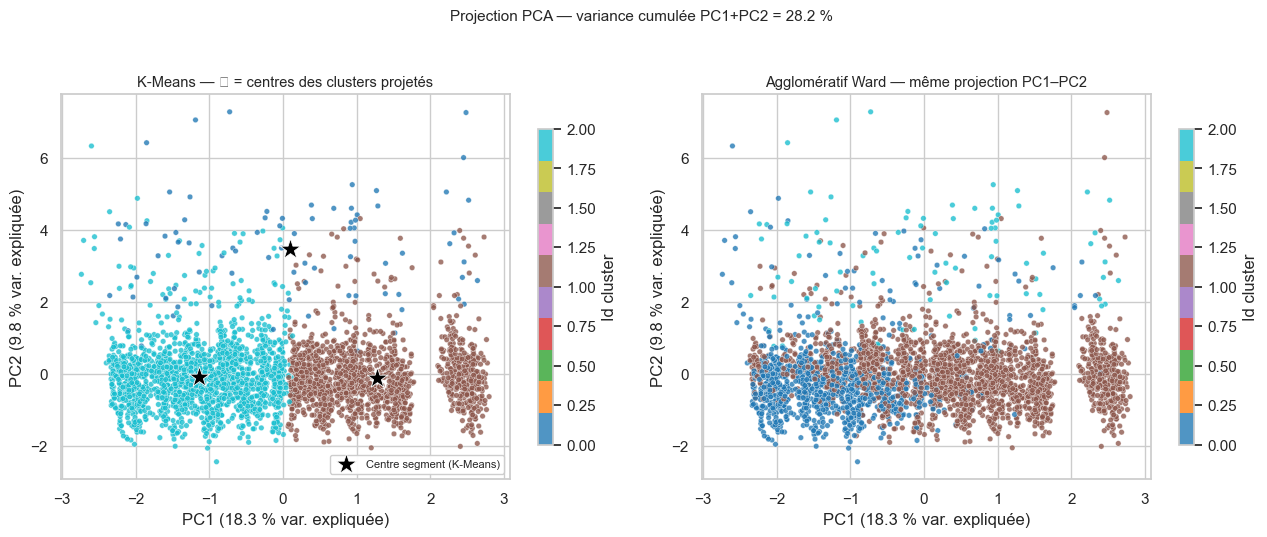

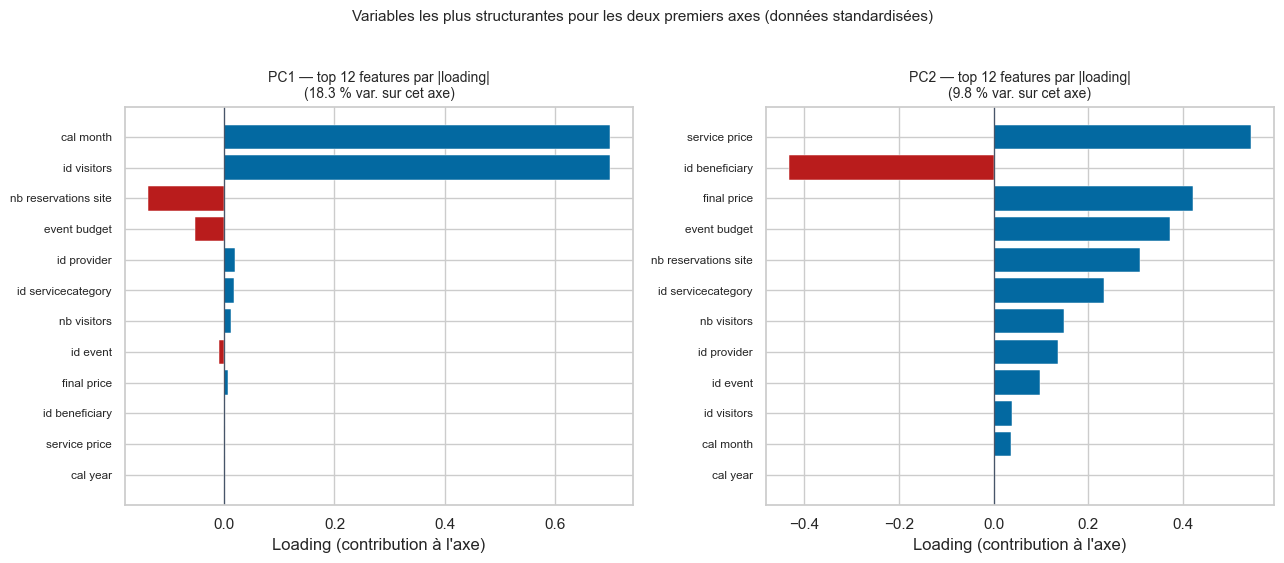

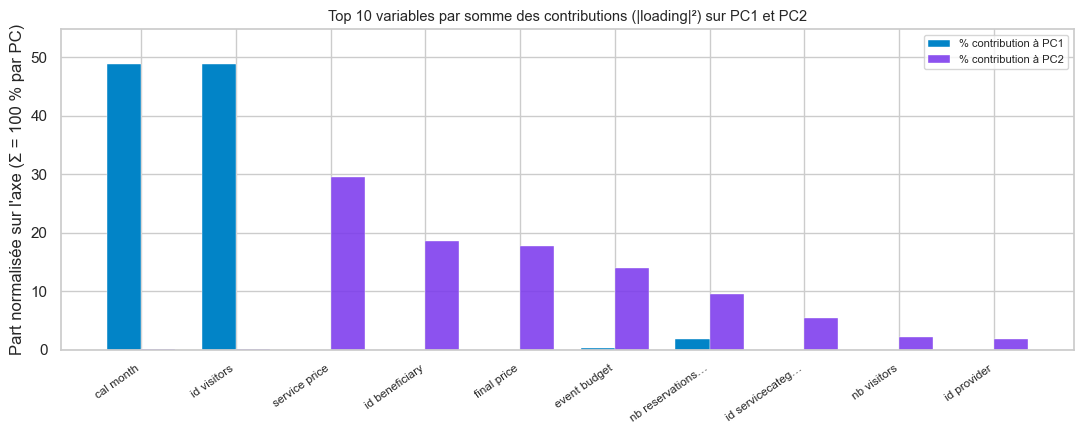


 INTERPRÉTATIONS DYNAMIQUES (basées sur cette exécution)
 (Périmètre : vue LARGE (une ligne ≈ fait / réservation dans X_work) — pas l’agrégat RFM par acteur.)
 (Repère graphique : abscisse = PC1, ordonnée = PC2 — aligné sur les figures ci-dessus.)

▸ PC1 (18.3 % de la variance totale)
   Lecture globale : cet axe exprime surtout un mélange calendrier (mois, année) et identifiants DW (visiteur, etc.) — axe interprétable comme « période × référentiel technique », d’après les variables aux loadings les plus marquants.
   Côté scores PC1 positifs (à droite si PC1, en haut si PC2) : «cal month» (+0.70), «id visitors» (+0.70)
   Côté scores PC1 négatifs (gauche si PC1, bas si PC2) : «nb reservations site» (-0.14)

▸ PC2 (9.8 % de la variance totale)
   Lecture globale : cet axe exprime surtout une dimension économique (prix, budget, tarifs), d’après les variables aux loadings les plus marquants.
   Côté scores PC2 positifs (à droite si PC1, en haut si PC2) : «service price» (+0.54), «final 

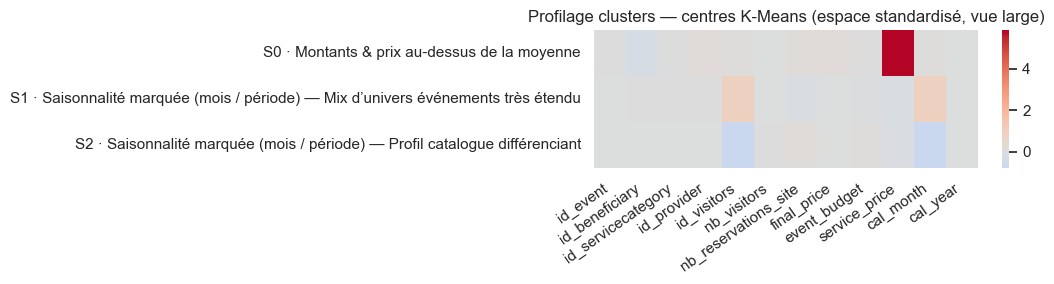

In [9]:
# PCA enrichie : projections 2D, centres des clusters projetés, loadings, heatmap (vue LARGE standardisée).
# Les agrégats fidélité RFM (*_loyalty) sont produits par run_01_clustering.py — pas ce bloc, sauf si vous
# les avez explicitement inclus dans X_work.
from ML.pca_interpretation_fr import print_pca_dynamic_interpretation
pca = PCA(n_components=2, random_state=42)
X2 = pca.fit_transform(X_work)
_evr = pca.explained_variance_ratio_
_v1, _v2 = float(_evr[0]), float(_evr[1])
_cum2 = _v1 + _v2

print("[4] PCA — variance expliquée PC1, PC2 :", round(_v1, 4), round(_v2, 4))
print("(Jeu : matrice standardisée issue de la vue large — pas les agrégats RFM du script fidélité.)")
print(
    f"Variance cumulée (PC1+PC2) : ~{_cum2 * 100:.1f} % de la variance totale "
    f"({X_work.shape[1]} variables en entrée, données standardisées)."
)

n_feat = pca.components_.shape[1]
_fn = (
    np.array(feat_names[:n_feat])
    if len(feat_names) >= n_feat
    else np.array([f"f{j}" for j in range(n_feat)])
)


def _fmt_feat(name, max_len=28):
    s = str(name).replace("_", " ")
    return s if len(s) <= max_len else s[: max_len - 1] + "…"


def _top_loading_indices(pc_idx, top=8):
    comp = pca.components_[pc_idx]
    ord_ = np.argsort(np.abs(comp))[-top:][::-1]
    return ord_, comp[ord_]


print()
print("--- Interprétation (PCA) — synthèse (vue large) ---")
print(
    "Chaque axe combine les variables **déjà standardisées** de la performance wide. "
    "Les **loadings** indiquent quelles features « tirent » le nuage (montants, volumes, calendrier, ids DW, etc.). "
    "Les profils fidélité (`*_loyalty`) sont hors de ce graphe sauf inclusion explicite dans X_work."
)
if _cum2 < 0.35:
    print(
        f"→ Part modérée sur 2 dimensions (~{_cum2 * 100:.0f} %) : les segments peuvent se chevaucher en projection ; "
        "compléter avec la heatmap des centres K-Means et les libellés de segment [3b]."
    )
elif _cum2 < 0.55:
    print(
        f"→ Environ la moitié de la variance sur PC1–PC2 (~{_cum2 * 100:.0f} %) : carte 2D utile mais partielle."
    )
else:
    print(
        f"→ Forte part de variance sur les deux premiers axes (~{_cum2 * 100:.0f} %) : la projection résume bien la dispersion."
    )

for j, pcname in enumerate(["PC1", "PC2"]):
    idx, vals = _top_loading_indices(j, top=6)
    pairs = [f"«{_fmt_feat(_fn[i])}» ({vals[k]:+.3f})" for k, i in enumerate(idx)]
    print(f"  {pcname} — variables à plus fort |loading| : {', '.join(pairs)}")

try:
    i1 = int(np.argmax(np.abs(pca.components_[0])))
    i2 = int(np.argmax(np.abs(pca.components_[1])))
    print()
    print(
        f"→ Lecture directe : PC1 est surtout porté par « {_fmt_feat(_fn[i1])} » "
        f"({'sens +' if pca.components_[0][i1] >= 0 else 'sens −'}) ; "
        f"PC2 par « {_fmt_feat(_fn[i2])} » "
        f"({'sens +' if pca.components_[1][i2] >= 0 else 'sens −'}). "
        "Relier ces noms à la structure du fait (montants, volumes, calendrier, dimensions) — "
        "cohérent avec [3b] ; distinct des métriques agrégées fidélité (script RFM)."
    )
except Exception:
    pass

print()

# Centres K-Means dans l'espace PCA (même ACP que les points)
_c2 = pca.transform(km.cluster_centers_)

fig1, axes = plt.subplots(1, 2, figsize=(13, 5.2))
_titles = (
    "K-Means — ★ = centres des clusters projetés",
    "Agglomératif Ward — même projection PC1–PC2",
)
for ax_idx, (labs, ttl) in enumerate(zip((labels_km, labels_agg), _titles)):
    ax = axes[ax_idx]
    sc = ax.scatter(
        X2[:, 0],
        X2[:, 1],
        c=labs,
        cmap="tab10",
        s=16,
        alpha=0.78,
        linewidths=0.3,
        edgecolors="white",
    )
    if ax_idx == 0:
        ax.scatter(
            _c2[:, 0],
            _c2[:, 1],
            c="black",
            marker="*",
            s=240,
            zorder=6,
            label="Centre segment (K-Means)",
            edgecolors="white",
            linewidths=0.6,
        )
        ax.legend(loc="best", fontsize=8, framealpha=0.95)
    ax.axhline(0, color="#94a3b8", lw=0.55, zorder=0)
    ax.axvline(0, color="#94a3b8", lw=0.55, zorder=0)
    ax.set_xlabel(f"PC1 ({100 * _v1:.1f} % var. expliquée)")
    ax.set_ylabel(f"PC2 ({100 * _v2:.1f} % var. expliquée)")
    ax.set_title(ttl, fontsize=10.5)
    plt.colorbar(sc, ax=ax, label="Id cluster", shrink=0.82)
fig1.suptitle(
    f"Projection PCA — variance cumulée PC1+PC2 = {_cum2 * 100:.1f} %",
    fontsize=11,
    y=1.03,
)
plt.tight_layout()
plt.show()

# Graphiques en barres : loadings (importance de chaque feature sur chaque axe)
n_top = min(12, n_feat)
fig2, axes2 = plt.subplots(1, 2, figsize=(13, 5.5))
for pc_idx, ax_b in enumerate(axes2):
    comp = pca.components_[pc_idx]
    ord_ = np.argsort(np.abs(comp))[-n_top:][::-1]
    vals = comp[ord_]
    labels_y = [_fmt_feat(_fn[i], 22) for i in ord_]
    colors = ["#0369a1" if v >= 0 else "#b91c1c" for v in vals]
    y_pos = np.arange(len(ord_))
    ax_b.barh(y_pos, vals, color=colors, edgecolor="white", linewidth=0.35)
    ax_b.set_yticks(y_pos)
    ax_b.set_yticklabels(labels_y, fontsize=8.5)
    ax_b.axvline(0, color="#475569", lw=0.9)
    ax_b.set_xlabel("Loading (contribution à l'axe)")
    pname = "PC1" if pc_idx == 0 else "PC2"
    ax_b.set_title(
        f"{pname} — top {n_top} features par |loading|\n({100 * _evr[pc_idx]:.1f} % var. sur cet axe)",
        fontsize=10,
    )
    ax_b.invert_yaxis()
fig2.suptitle(
    "Variables les plus structurantes pour les deux premiers axes (données standardisées)",
    fontsize=11,
    y=1.02,
)
plt.tight_layout()
plt.show()

# Part relative du carré des loadings sur chaque PC (part de « poids » sur l'axe, top variables)
sq1 = pca.components_[0] ** 2
sq2 = pca.components_[1] ** 2
q1 = 100.0 * sq1 / sq1.sum()
q2 = 100.0 * sq2 / sq2.sum()
n_b = min(10, n_feat)
ord_mix = np.argsort(q1 + q2)[-n_b:][::-1]
fig3, ax3 = plt.subplots(figsize=(11, 4.5))
x = np.arange(len(ord_mix))
w = 0.36
ax3.bar(x - w / 2, q1[ord_mix], width=w, label="% contribution à PC1", color="#0284c7", edgecolor="white", linewidth=0.3)
ax3.bar(
    x + w / 2,
    q2[ord_mix],
    width=w,
    label="% contribution à PC2",
    color="#7c3aed",
    alpha=0.88,
    edgecolor="white",
    linewidth=0.3,
)
ax3.set_xticks(x)
ax3.set_xticklabels([_fmt_feat(_fn[i], 16) for i in ord_mix], rotation=35, ha="right", fontsize=8.5)
ax3.set_ylabel("Part normalisée sur l'axe (Σ = 100 % par PC)")
ax3.set_title(
    f"Top {n_b} variables par somme des contributions (|loading|²) sur PC1 et PC2",
    fontsize=10.5,
)
ax3.legend(loc="upper right", fontsize=8)
ax3.set_ylim(0, max(q1[ord_mix].max(), q2[ord_mix].max()) * 1.12)
plt.tight_layout()
plt.show()

print_pca_dynamic_interpretation(
    pca,
    X2,
    _fn,
    labels_km,
    labels_agg,
    _c2,
    k_best,
    cluster_label_short,
    km_cluster_centers=km.cluster_centers_,
    feat_names_original=list(feat_names) if feat_names else None,
    scope="wide",
)

print()
print("--- Interprétation (heatmap des centres K-Means, vue large) ---")
print("Chaque LIGNE (S0, S1, …) = profil moyen d'un segment dans l'espace STANDARDISÉ (z-score).")
print("Chaque COLONNE = une variable de la vue performance (montant, id dimension, temps, …).")
print("Couleur chaude = au-dessus de la moyenne globale sur cette variable ; froide = en dessous.")
print("Le libellé à gauche résume les facettes dominantes (voir cellule [3b]).")
print(
    "Croiser : segment chaud sur une variable → cette variable apparaît souvent en tête des loadings PCA. "
    "Pour les segments **fidélité RFM**, utiliser les sorties `loyalty_*` / `run_01_clustering.py`."
)
print()

n_show = min(20, km.cluster_centers_.shape[1])
cols = feat_names[:n_show] if len(feat_names) >= n_show else [f"f{i}" for i in range(n_show)]
hm = km.cluster_centers_[:, :n_show]
_y_hm = [f"S{i} · {cluster_label_short[i]}" for i in range(k_best)]
plt.figure(figsize=(11, max(3, k_best * 0.45)))
sns.heatmap(hm, annot=False, cmap="coolwarm", center=0, xticklabels=cols, yticklabels=_y_hm)
plt.title("Profilage clusters — centres K-Means (espace standardisé, vue large)")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


### Après PCA & heatmap

Cohérence **heatmap** ↔ **loadings** : un segment dominant sur une variable du plan PCA apparaît souvent en loading, si cette variable structure aussi le nuage global.

**Prudence** : PCA linéaire ; interactions fortes peuvent rester hors PC1–2.


## 5. Export (wide) & rappel fidélité

Cette section sauve le K-Means **wide** (legacy). Pour **Streamlit / fidélité**, privilégier `run_01_clustering.py` (ne pas écraser les artefacts fidélité sans sauvegarde).

**Résultat attendu** : message `[5]` ; fichiers listés en console.


In [10]:
# Export « wide » (legacy). Pour fidélité RFM + Streamlit : préférer REPO_ROOT / "ML/scripts/run_01_clustering.py".
# import subprocess; subprocess.run([sys.executable, str(REPO_ROOT / "ML" / "scripts" / "run_01_clustering.py")], check=False)
joblib.dump(km_final, ML_MODELS / "kmeans_kpi_segments.joblib")
joblib.dump(scaler, ML_MODELS / "kmeans_standard_scaler.joblib")
joblib.dump(imp, ML_MODELS / "kmeans_median_imputer.joblib")
_share_ser = pd.Series(labels).value_counts(normalize=True).sort_index()
metrics = {
    "task": "clustering",
    "model_primary": "KMeans",
    "model_secondary": "AgglomerativeClustering_ward",
    "k": k_best,
    "silhouette": float(sil),
    "silhouette_train": float(sil_train),
    "silhouette_holdout": float(sil_hold),
    "silhouette_kmeans_full": sil_km,
    "silhouette_agg_full": sil_agg,
    "davies_bouldin_kmeans": db_km,
    "davies_bouldin_agg": db_agg,
    "n_samples": n,
    "n_train": int(len(X_train)),
    "n_holdout": int(len(X_hold)),
    "kpi_alignment": "diversite_offre_segments_critere_E",
    "cluster_segment_labels_file": "clustering_segment_labels.json",
    "cluster_feature_names_file": "clustering_feature_names.json",
    "cluster_share_train_sample": {str(int(i)): float(_share_ser.get(i, 0.0)) for i in range(k_best)},
}
(ML_MODELS / "metrics_clustering.json").write_text(json.dumps(metrics, indent=2), encoding="utf-8")
(ML_MODELS / "clustering_feature_names.json").write_text(
    json.dumps({"features": feat_names}, ensure_ascii=False, indent=2),
    encoding="utf-8",
)
_seg_doc = {
    "k": k_best,
    "method": "facettes_metier_centres_standardises",
    "description_fr": "Libellés à partir des centres K-Means : moyenne des z-scores par facette (montants, volumes, calendrier, IDs), priorité métier sur les clés techniques ; repli 2 axes si noms génériques dim_*.",
    "segments": [
        {
            "cluster_id": i,
            "label_short": cluster_label_short[i],
            "label_long_plain": cluster_label_long[i].replace("**", ""),
            "share_train_sample": float(_share_ser.get(i, 0.0)),
        }
        for i in range(k_best)
    ],
}
(ML_MODELS / "clustering_segment_labels.json").write_text(
    json.dumps(_seg_doc, ensure_ascii=False, indent=2),
    encoding="utf-8",
)
print("[5] kmeans + imputer (médianes) + scaler + metrics + clustering_feature_names.json + clustering_segment_labels.json.")


[5] kmeans + imputer (médianes) + scaler + metrics + clustering_feature_names.json + clustering_segment_labels.json.


### Après sauvegarde

- **`kmeans_kpi_segments.joblib`** = wide notebook ; **`kmeans_loyalty_*.joblib`** = script fidélité.
- **`metrics_clustering.json`** : format legacy vs bloc `modes` (fidélité).

Pour la **soutenance E** : citer **comparaison 2 modèles** + figures ; pour la **démo app** : citer script + `loyalty_*`.


### Synthèse E

| Point | Contenu |
|-------|---------|
| Non supervisé | Pas de Y ; segments par distance |
| 2 modèles | K-Means vs Ward |
| k | Coude + silhouette |
| Lecture | PCA + heatmap ; fidélité via script |

